<a href="https://colab.research.google.com/github/Nadia-dia/data-mining-projects/blob/main/eksploracja_danych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksploracja Danych – Projekt
## Zbiory: Wine Quality (red + white) | Loan Approval | Adult Income

---

## 1. Cele eksploracji

| Zbiór | Zadanie | Typ problemu |
|---|---|---|
| **Wine Quality** | Przewidywanie jakości wina (ocena 0–10) na podstawie parametrów fizykochemicznych | Klasyfikacja wieloklasowa / Regresja |
| **Loan Approval** | Przewidywanie, czy wniosek o pożyczkę zostanie zaakceptowany (Y/N) | Klasyfikacja binarna |
| **Adult Income** | Przewidywanie, czy dochód osoby przekracza 50K USD rocznie | Klasyfikacja binarna |

**Cele ekploracji:**
- Jakie cechy chemiczne najbardziej wpływają na ocenę jakości wina? Czy różnią się dla win czerwonych i białych?
- Jakie czynniki (historia kredytowa, dochód, wykształcenie) decydują o przyznaniu pożyczki?
- Jak wiek, wykształcenie, płeć i liczba godzin pracy korelują z wysokością dochodu?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('Biblioteki załadowane ✓')

Biblioteki załadowane ✓


---
## 2. Wine Quality – Analiza eksploracyjna
Zbiór składa się z dwóch plików: `winequality-red.csv` (1 599 próbek) i `winequality-white.csv` (4 898 próbek).
Łączymy je i dodajemy kolumnę `type`.

In [ ]:
# Oryginalne pliki UCI używają średnika jako separatora
# Jeśli masz pliki z przecinkiem (np. z Kaggle), zmień sep=';' na sep=','
red   = pd.read_csv('winequality-red.csv',   sep=None, engine='python')
white = pd.read_csv('winequality-white.csv', sep=None, engine='python')

# Ujednolicenie nazw kolumn (UCI ma spacje, niektóre wersje mają _)
red.columns   = red.columns.str.strip()
white.columns = white.columns.str.strip()

if 'type' not in red.columns:   red['type']   = 'red'
if 'type' not in white.columns: white['type'] = 'white'
wine = pd.concat([red, white], ignore_index=True)

print(f'Czerwone:  {red.shape[0]:,} rekordów, {red.shape[1]} kolumn')
print(f'Białe:     {white.shape[0]:,} rekordów, {white.shape[1]} kolumn')
print(f'Łącznie:   {wine.shape[0]:,} rekordów')
print(f'Kolumny:   {list(wine.columns)}')
wine.head()

Czerwone:  1,599 rekordów, 13 kolumn
Białe:     4,898 rekordów, 13 kolumn
Łącznie:   6,497 rekordów
Kolumny:   ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [ ]:
print('=== Typy zmiennych ===')
print(wine.dtypes)
print('\n=== Statystyki opisowe ===')
wine.describe().round(3)

=== Typy zmiennych ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

=== Statystyki opisowe ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


In [ ]:
# Braki danych
for label, df in [('Czerwone', red), ('Białe', white), ('Łącznie', wine)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss):
        pct = (miss / len(df) * 100).round(2)
        print(f'\n--- {label} ---')
        print(pd.DataFrame({'Braki': miss, '%': pct}))
    else:
        print(f'\n--- {label}: brak braków danych ---')


--- Czerwone: brak braków danych ---

--- Białe: brak braków danych ---

--- Łącznie: brak braków danych ---


In [ ]:
# Duplikaty i outliers IQR
print(f'Duplikaty (red):   {red.drop(columns="type").duplicated().sum()}')
print(f'Duplikaty (white): {white.drop(columns="type").duplicated().sum()}')
print()
for col in ['volatile acidity', 'residual sugar', 'total sulfur dioxide', 'chlorides']:
    for grp, lbl in [(red, 'red'), (white, 'white')]:
        Q1, Q3 = grp[col].quantile(0.25), grp[col].quantile(0.75)
        n_out  = ((grp[col] < Q1-1.5*(Q3-Q1)) | (grp[col] > Q3+1.5*(Q3-Q1))).sum()
        print(f'  Outliers [{lbl}] [{col}]: {n_out} ({n_out/len(grp)*100:.1f}%)')

Duplikaty (red):   240
Duplikaty (white): 937

  Outliers [red] [volatile acidity]: 19 (1.2%)
  Outliers [white] [volatile acidity]: 186 (3.8%)
  Outliers [red] [residual sugar]: 155 (9.7%)
  Outliers [white] [residual sugar]: 7 (0.1%)
  Outliers [red] [total sulfur dioxide]: 55 (3.4%)
  Outliers [white] [total sulfur dioxide]: 19 (0.4%)
  Outliers [red] [chlorides]: 112 (7.0%)
  Outliers [white] [chlorides]: 208 (4.2%)


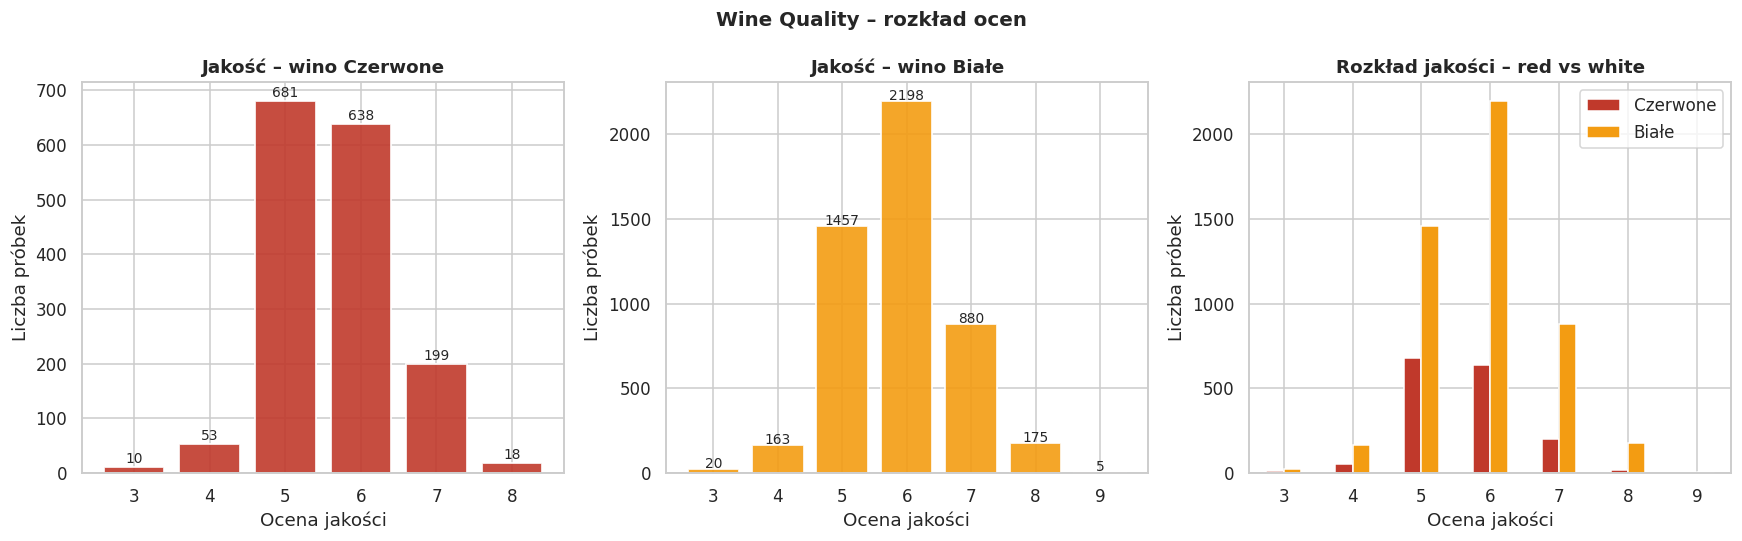

In [ ]:
# VIZ 1 – Rozkład jakości red vs white
palette = {'red': '#c0392b', 'white': '#f39c12'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, grp, label in zip(axes[:2], ['red','white'], ['Czerwone','Białe']):
    vc = wine[wine['type']==grp]['quality'].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=palette[grp], edgecolor='white', linewidth=1.2, alpha=0.9)
    ax.set_title(f'Jakość – wino {label}', fontweight='bold')
    ax.set_xlabel('Ocena jakości'); ax.set_ylabel('Liczba próbek')
    for k, v in vc.items(): ax.text(k, v+8, str(v), ha='center', fontsize=9)

ct = pd.crosstab(wine['quality'], wine['type'])
ct.plot(kind='bar', ax=axes[2], color=[palette['red'], palette['white']], rot=0, edgecolor='white')
axes[2].set_title('Rozkład jakości – red vs white', fontweight='bold')
axes[2].set_xlabel('Ocena jakości'); axes[2].set_ylabel('Liczba próbek')
axes[2].legend(['Czerwone','Białe'])

plt.suptitle('Wine Quality – rozkład ocen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_quality_dist.png', bbox_inches='tight')
plt.show()

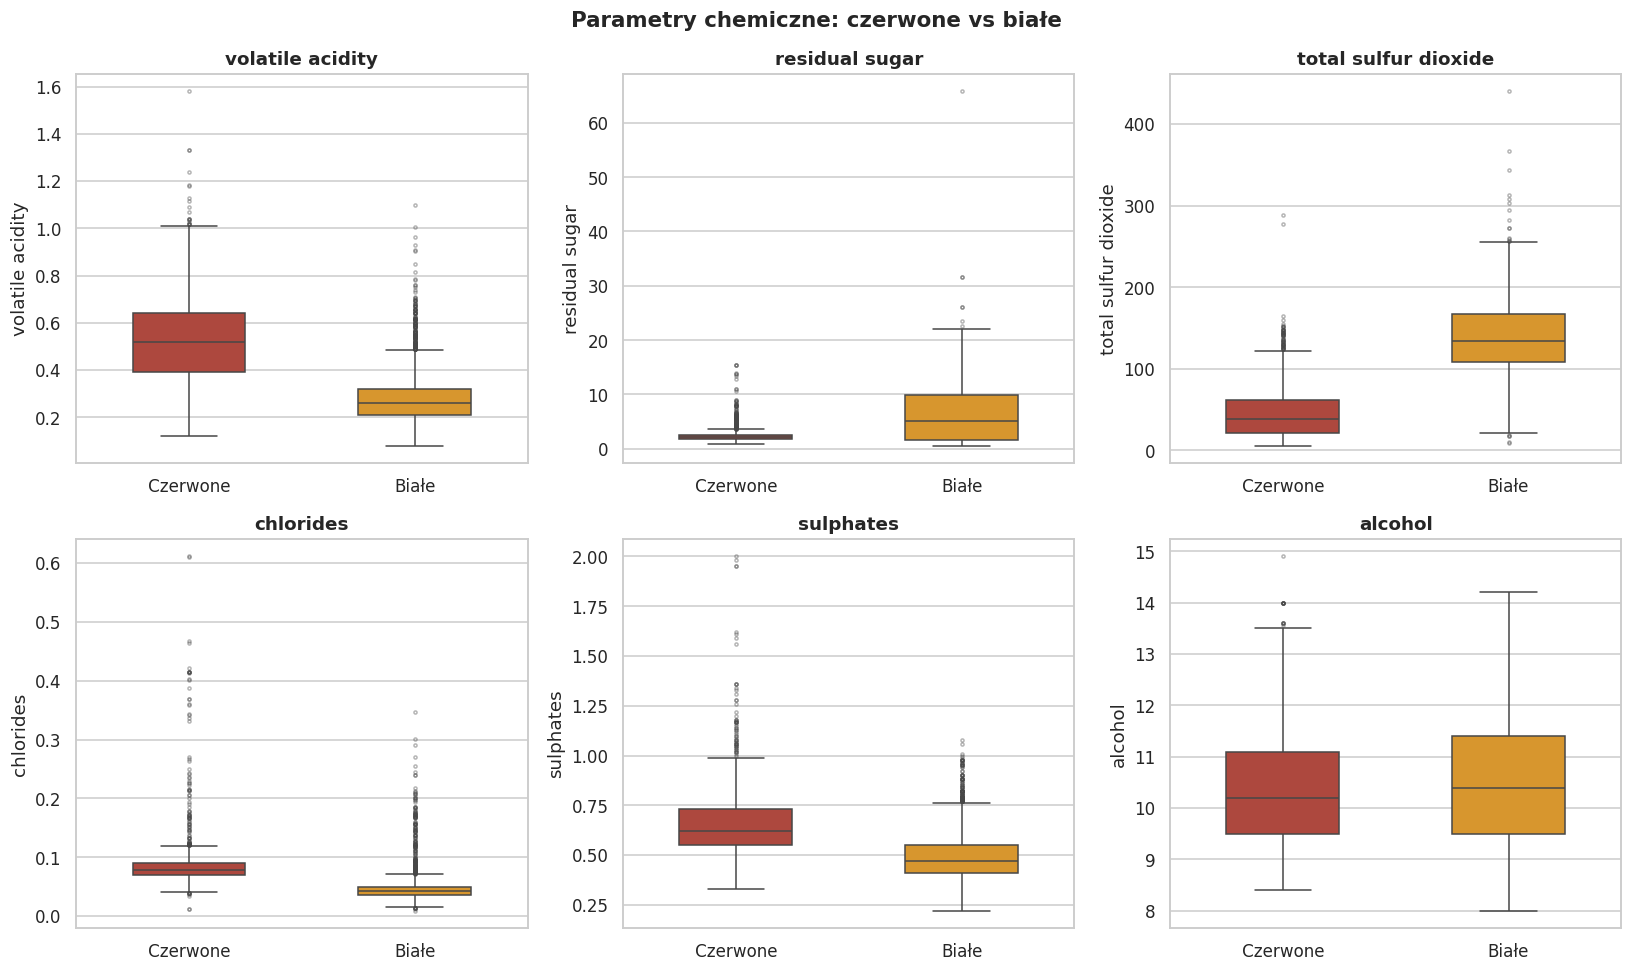

In [ ]:
# VIZ 2 – Różnice chemiczne red vs white
diff_features = ['volatile acidity','residual sugar','total sulfur dioxide',
                 'chlorides','sulphates','alcohol']
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, feat in zip(axes.flatten(), diff_features):
    sns.boxplot(x='type', y=feat, data=wine, palette=palette, ax=ax,
                width=0.5, flierprops=dict(marker='o', markersize=2, alpha=0.4))
    ax.set_title(feat, fontweight='bold')
    ax.set_xticklabels(['Czerwone','Białe'])
    ax.set_xlabel('')
plt.suptitle('Parametry chemiczne: czerwone vs białe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('wine_chemistry_comparison.png', bbox_inches='tight')
plt.show()

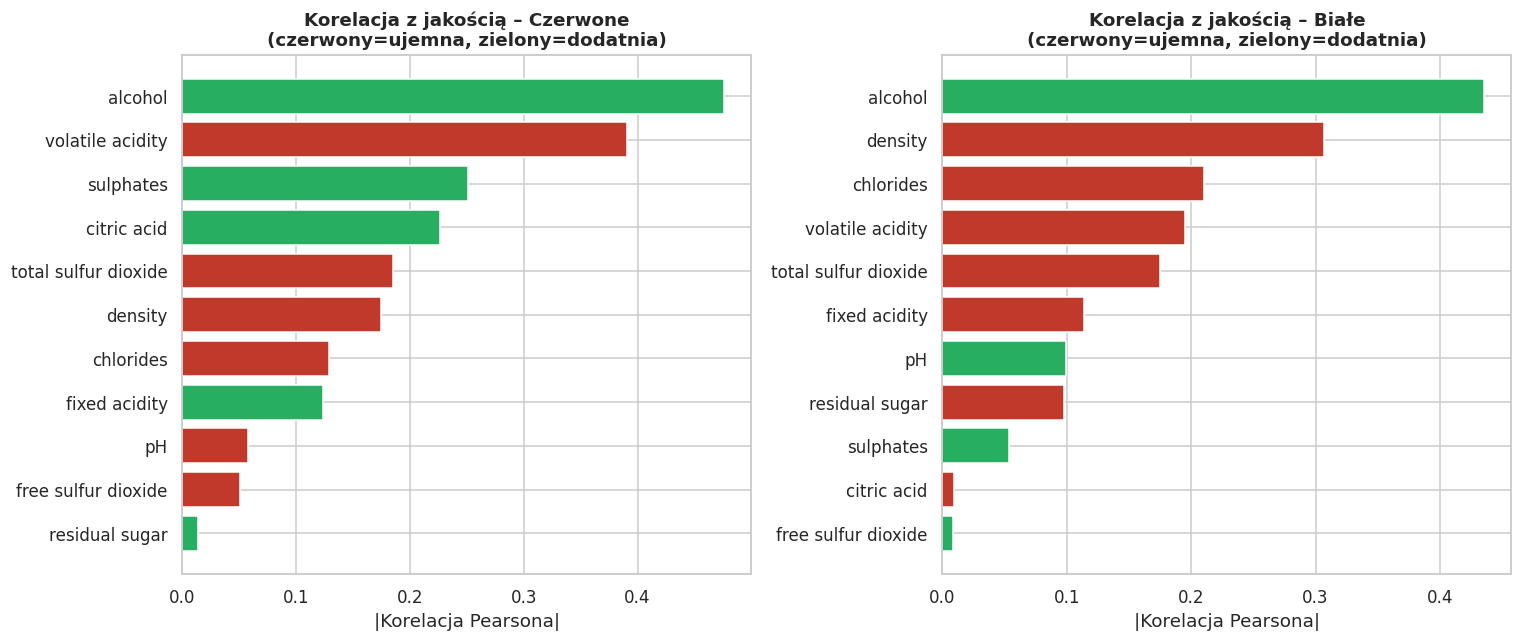

In [ ]:
# VIZ 3 – Korelacja z jakością osobno dla red i white
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, grp, label in zip(axes, ['red','white'], ['Czerwone','Białe']):
    sub   = wine[wine['type']==grp].drop(columns='type')
    corr  = sub.corr()['quality'].drop('quality')
    order = corr.abs().sort_values()
    colors = ['#c0392b' if corr[i] < 0 else '#27ae60' for i in order.index]
    ax.barh(order.index, order.values, color=colors)
    ax.set_title(f'Korelacja z jakością – {label}\n(czerwony=ujemna, zielony=dodatnia)', fontweight='bold')
    ax.set_xlabel('|Korelacja Pearsona|')
plt.tight_layout()
plt.savefig('wine_correlations.png', bbox_inches='tight')
plt.show()

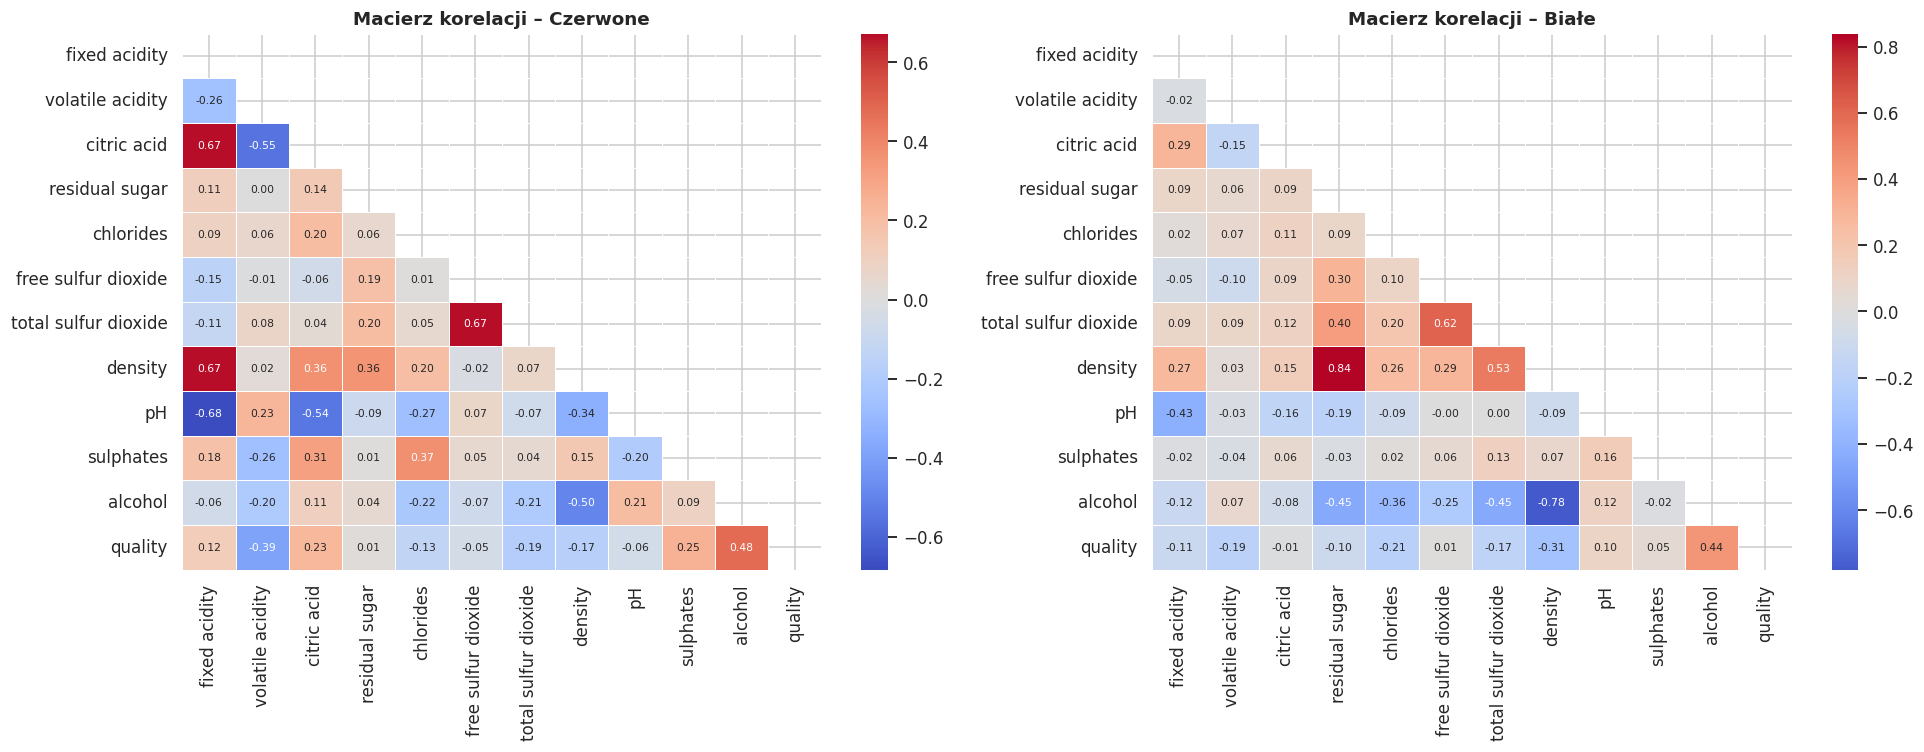

In [ ]:
# VIZ 4 – Macierze korelacji red i white
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, grp, label in zip(axes, ['red','white'], ['Czerwone','Białe']):
    sub  = wine[wine['type']==grp].drop(columns='type')
    mask = np.triu(np.ones_like(sub.corr(), dtype=bool))
    sns.heatmap(sub.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, linewidths=0.4, annot_kws={'size': 7})
    ax.set_title(f'Macierz korelacji – {label}', fontweight='bold')
plt.tight_layout()
plt.savefig('wine_heatmaps.png', bbox_inches='tight')
plt.show()

**Wnioski – Wine Quality:**
- Białe wina dominują liczebnie (4 898 vs 1 599) – przy modelowaniu `type` powinno być cechą
- Białe mają znacznie wyższy `residual sugar` i `total sulfur dioxide`; czerwone wyższy `volatile acidity` i `sulphates`
- Dla czerwonych: `alcohol` (+) i `volatile acidity` (–) to dominujące predyktory jakości
- Dla białych: `alcohol` (+) i `density` (–) korelują z jakością mocniej niż w czerwonych
- Klasy 3 i 8 są rzadkie w obu typach → niezbalansowanie wymaga stratified split lub SMOTE

---
## 3. Loan Approval – Analiza eksploracyjna

In [ ]:
loan = pd.read_csv('loan.csv')
print(f'Rekordy: {loan.shape[0]:,}  |  Kolumny: {loan.shape[1]}')
loan.head()

Rekordy: 614  |  Kolumny: 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
print('=== Typy zmiennych ===')
print(loan.dtypes)
print('\n=== Statystyki opisowe – numeryczne ===')
loan.describe().round(2)

=== Typy zmiennych ===
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

=== Statystyki opisowe – numeryczne ===


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.00,614.00,592.00,600.00,564.00
mean,5403.46,1621.25,146.41,342.00,0.84
std,6109.04,2926.25,85.59,65.12,0.36
min,150.00,0.00,9.00,12.00,0.00
25%,2877.50,0.00,100.00,360.00,1.00
50%,3812.50,1188.50,128.00,360.00,1.00
75%,5795.00,2297.25,168.00,360.00,1.00
max,81000.00,41667.00,700.00,480.00,1.00


In [ ]:
print('=== Statystyki opisowe – kategoryczne ===')
loan.describe(include='object')

=== Statystyki opisowe – kategoryczne ===


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
# Braki danych
miss = loan.isnull().sum()
miss = miss[miss > 0]
pct  = (miss / len(loan) * 100).round(2)
print('=== Braki danych – Loan ===')
print(pd.DataFrame({'Braki': miss, '%': pct}))
print(f'\nDuplikaty: {loan.duplicated().sum()}')

=== Braki danych – Loan ===
                  Braki     %
Gender               13  2.12
Married               3  0.49
Dependents           15  2.44
Self_Employed        32  5.21
LoanAmount           22  3.58
Loan_Amount_Term     14  2.28
Credit_History       50  8.14

Duplikaty: 0


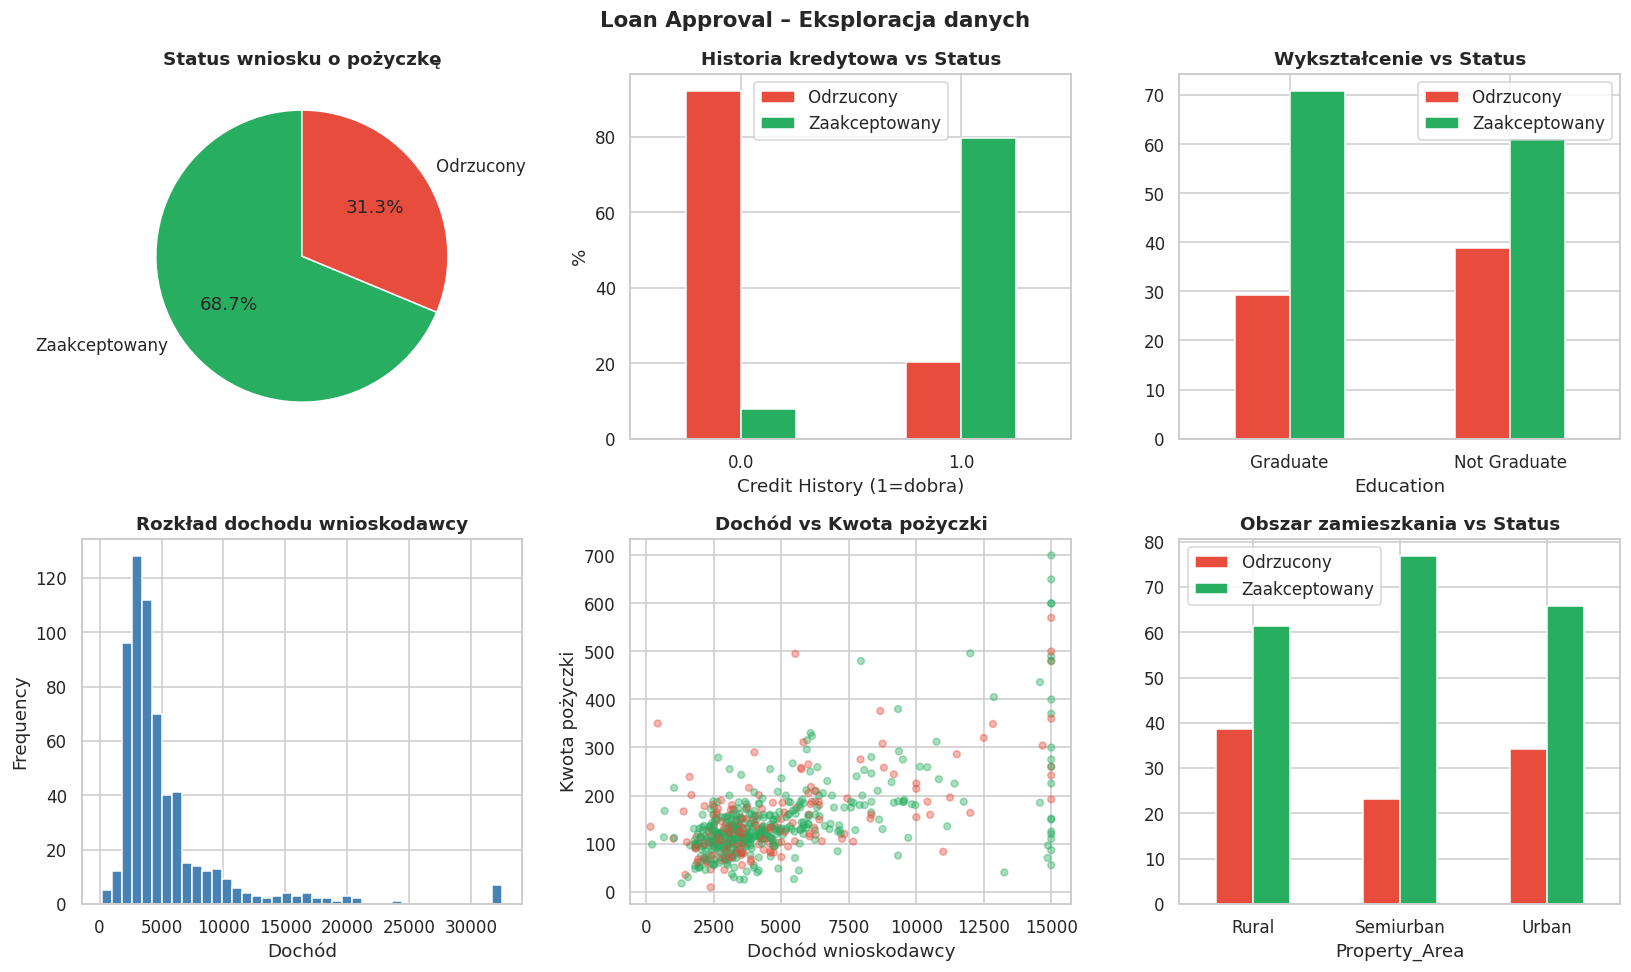

In [ ]:
# VIZ 5 – Loan overview
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Zmienna docelowa
vc = loan['Loan_Status'].value_counts()
axes[0,0].pie(vc.values, labels=['Zaakceptowany','Odrzucony'], autopct='%1.1f%%',
              colors=['#27ae60','#e74c3c'], startangle=90)
axes[0,0].set_title('Status wniosku o pożyczkę', fontweight='bold')

# Historia kredytowa vs status
ct = pd.crosstab(loan['Credit_History'], loan['Loan_Status'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[0,1], color=['#e74c3c','#27ae60'], rot=0)
axes[0,1].set_title('Historia kredytowa vs Status', fontweight='bold')
axes[0,1].set_xlabel('Credit History (1=dobra)')
axes[0,1].set_ylabel('%')
axes[0,1].legend(['Odrzucony','Zaakceptowany'])

# Wykształcenie vs status
ct2 = pd.crosstab(loan['Education'], loan['Loan_Status'], normalize='index') * 100
ct2.plot(kind='bar', ax=axes[0,2], color=['#e74c3c','#27ae60'], rot=0)
axes[0,2].set_title('Wykształcenie vs Status', fontweight='bold')
axes[0,2].legend(['Odrzucony','Zaakceptowany'])

# Rozkład dochodu
loan['ApplicantIncome'].clip(upper=loan['ApplicantIncome'].quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Rozkład dochodu wnioskodawcy', fontweight='bold')
axes[1,0].set_xlabel('Dochód')

# Dochód vs kwota pożyczki
colors_s = loan['Loan_Status'].map({'Y':'#27ae60','N':'#e74c3c'})
axes[1,1].scatter(loan['ApplicantIncome'].clip(upper=15000), loan['LoanAmount'],
                  c=colors_s, alpha=0.4, s=20)
axes[1,1].set_title('Dochód vs Kwota pożyczki', fontweight='bold')
axes[1,1].set_xlabel('Dochód wnioskodawcy'); axes[1,1].set_ylabel('Kwota pożyczki')

# Obszar zamieszkania vs status
ct3 = pd.crosstab(loan['Property_Area'], loan['Loan_Status'], normalize='index') * 100
ct3.plot(kind='bar', ax=axes[1,2], color=['#e74c3c','#27ae60'], rot=0)
axes[1,2].set_title('Obszar zamieszkania vs Status', fontweight='bold')
axes[1,2].legend(['Odrzucony','Zaakceptowany'])

plt.suptitle('Loan Approval – Eksploracja danych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('loan_overview.png', bbox_inches='tight')
plt.show()

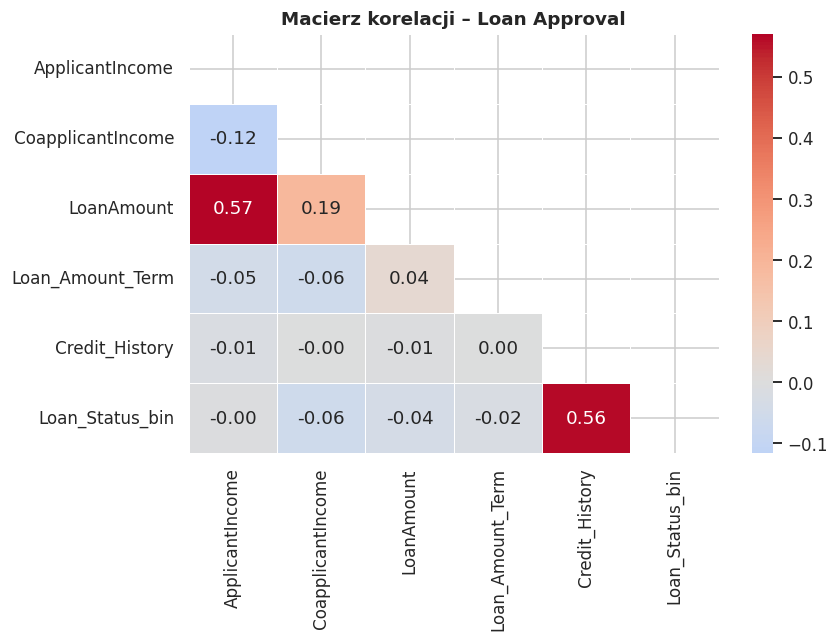

In [ ]:
# VIZ 6 – Macierz korelacji (numeryczne)
loan_num = loan.select_dtypes(include=np.number).copy()
loan_num['Loan_Status_bin'] = (loan['Loan_Status'] == 'Y').astype(int)
mask = np.triu(np.ones_like(loan_num.corr(), dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loan_num.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Macierz korelacji – Loan Approval', fontweight='bold')
plt.tight_layout()
plt.savefig('loan_corr.png', bbox_inches='tight')
plt.show()

**Wnioski – Loan Approval:**
- Zbiór jest **niezbalansowany**: ~86% wniosków zaakceptowanych – wymaga class_weight lub SMOTE
- `Credit_History` to najsilniejszy predyktor: wnioskodawcy z dobrą historią akceptowani w ~90% przypadków
- Wykształcenie wyższe nieznacznie zwiększa szanse; obszar Semiurban ma najwyższy wskaźnik akceptacji
- Braki danych: 2–8% w kilku kolumnach; `Credit_History` (~8%) wymaga ostrożnej imputacji

---
## 4. Adult Income – Analiza eksploracyjna

In [ ]:
adult = pd.read_csv('adult.csv')
print(f'Rekordy: {adult.shape[0]:,}  |  Kolumny: {adult.shape[1]}')
adult.head()

Rekordy: 32,561  |  Kolumny: 15


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
print('=== Typy zmiennych ===')
print(adult.dtypes)
print('\n=== PODSTAWOWE STATYSTYKI (NUMERYCZNE) ===')
print(adult.describe().round(2))

print("=== PODSTAWOWE STATYSTYKI (KATEGORYCZNE) ===")
print(df.describe(include=["object"]), "\n")

=== Typy zmiennych ===
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

=== PODSTAWOWE STATYSTYKI (NUMERYCZNE) ===
            age      fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.00    32561.00       32561.00      32561.00      32561.00   
mean      38.58   189778.37          10.08       1077.65         87.30   
std       13.64   105549.98           2.57       7385.29        402.96   
min       17.00    12285.00           1.00          0.00          0.00   
25%       28.00   117827.00           9.00          0.00          0.00   
50%       37.00   178356.00          10.00          0.00          0.00   
75%       48.00   237051.0

In [ ]:
# Braki danych (w tym ukryte jako '?')
adult_clean = adult.replace('?', np.nan)
miss = adult_clean.isnull().sum()
miss = miss[miss > 0]
pct  = (miss / len(adult) * 100).round(2)
print('=== Braki danych (wliczając "?") – Adult ===')
print(pd.DataFrame({'Braki': miss, '%': pct}))
print(f'\nDuplikaty: {adult.duplicated().sum()}')
print()

=== Braki danych (wliczając "?") – Adult ===
                Braki     %
workclass        1836  5.64
occupation       1843  5.66
native.country    583  1.79

Duplikaty: 24


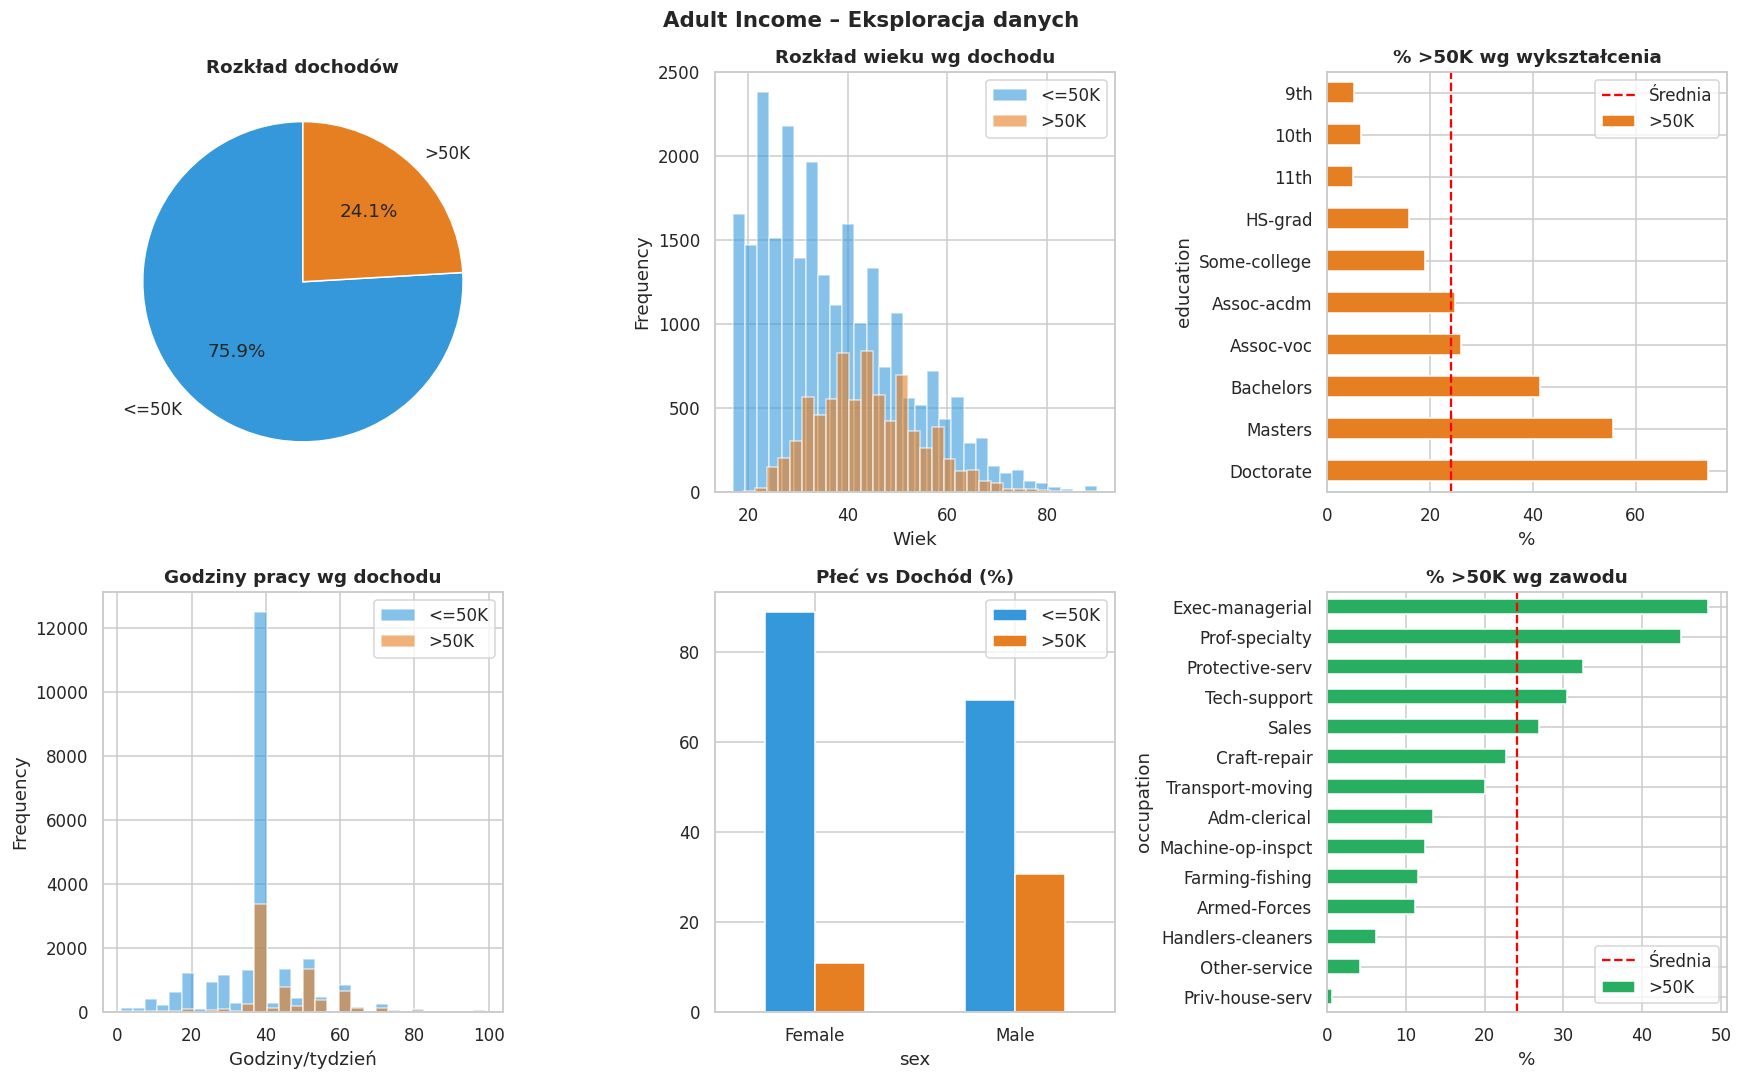

In [ ]:
# VIZ 7 – Adult overview
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Zmienna docelowa
vc = adult['income'].value_counts()
axes[0,0].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
              colors=['#3498db','#e67e22'], startangle=90)
axes[0,0].set_title('Rozkład dochodów', fontweight='bold')

# Wiek wg dochodu
for inc, col in zip(['<=50K','>50K'], ['#3498db','#e67e22']):
    adult[adult['income']==inc]['age'].plot(kind='hist', bins=30, alpha=0.6,
                                            ax=axes[0,1], color=col, label=inc)
axes[0,1].set_title('Rozkład wieku wg dochodu', fontweight='bold')
axes[0,1].set_xlabel('Wiek'); axes[0,1].legend()

# Wykształcenie vs % >50K
edu_order = ['Doctorate','Masters','Bachelors','Assoc-voc','Assoc-acdm',
             'Some-college','HS-grad','11th','10th','9th']
ct_edu = pd.crosstab(adult['education'], adult['income'], normalize='index') * 100
ct_edu = ct_edu.reindex([e for e in edu_order if e in ct_edu.index])
ct_edu['>50K'].plot(kind='barh', ax=axes[0,2], color='#e67e22')
axes[0,2].axvline(adult['income'].eq('>50K').mean()*100, color='red',
                  linestyle='--', label='Średnia')
axes[0,2].set_title('% >50K wg wykształcenia', fontweight='bold')
axes[0,2].set_xlabel('%'); axes[0,2].legend()

# Godziny pracy wg dochodu
for inc, col in zip(['<=50K','>50K'], ['#3498db','#e67e22']):
    adult[adult['income']==inc]['hours.per.week'].plot(
        kind='hist', bins=30, alpha=0.6, ax=axes[1,0], color=col, label=inc)
axes[1,0].set_title('Godziny pracy wg dochodu', fontweight='bold')
axes[1,0].set_xlabel('Godziny/tydzień'); axes[1,0].legend()

# Płeć vs dochód
ct_sex = pd.crosstab(adult['sex'], adult['income'], normalize='index') * 100
ct_sex.plot(kind='bar', ax=axes[1,1], color=['#3498db','#e67e22'], rot=0)
axes[1,1].set_title('Płeć vs Dochód (%)', fontweight='bold')
axes[1,1].legend(['<=50K','>50K'])

# Zawód vs % >50K
ct_occ = pd.crosstab(adult['occupation'], adult['income'], normalize='index') * 100
ct_occ = ct_occ[ct_occ.index != '?'].sort_values('>50K')
ct_occ['>50K'].plot(kind='barh', ax=axes[1,2], color='#27ae60')
axes[1,2].axvline(adult['income'].eq('>50K').mean()*100, color='red',
                  linestyle='--', label='Średnia')
axes[1,2].set_title('% >50K wg zawodu', fontweight='bold')
axes[1,2].set_xlabel('%'); axes[1,2].legend()

plt.suptitle('Adult Income – Eksploracja danych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('adult_overview.png', bbox_inches='tight')
plt.show()

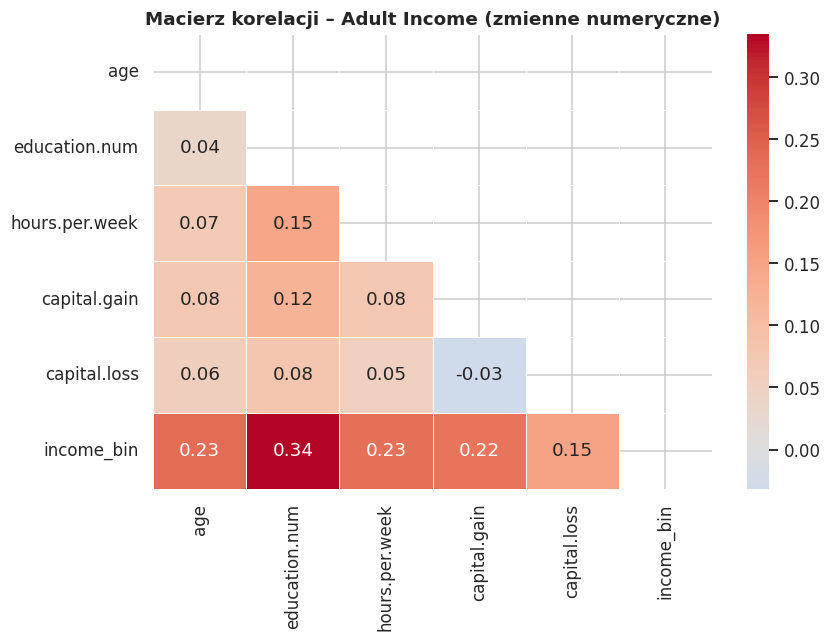

In [ ]:
# VIZ 8 – Macierz korelacji zmiennych numerycznych
num_cols = ['age','education.num','hours.per.week','capital.gain','capital.loss']
adult_num = adult[num_cols].copy()
adult_num['income_bin'] = (adult['income'] == '>50K').astype(int)
mask = np.triu(np.ones_like(adult_num.corr(), dtype=bool))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(adult_num.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5)
ax.set_title('Macierz korelacji – Adult Income (zmienne numeryczne)', fontweight='bold')
plt.tight_layout()
plt.savefig('adult_corr.png', bbox_inches='tight')
plt.show()

**Wnioski – Adult Income:**
- Zbiór zawiera ~37% osób z dochodem >50K – pewna nierównowaga, ale mniejsza niż w Loan
- `education-num` i `age` mają najsilniejszą korelację z dochodem spośród zmiennych numerycznych
- Osoby z doktoratem/magistrem zarabiają >50K w ponad 60% przypadków; absolwenci szkół średnich poniżej 15%
- Nierówności płciowe: mężczyźni zarabiają >50K ~2× częściej niż kobiety
- Exec-managerial i Prof-specialty to zawody z najwyższym odsetkiem >50K
- Braki ukryte jako `?` (~5%) w workclass, occupation, native-country – wymagają zamiany na NaN

---
## 5. Podsumowanie jakości danych

In [ ]:
summary = []
for name, df in [('Wine Quality (red)', red), ('Wine Quality (white)', white),
                 ('Loan Approval', loan), ('Adult Income', adult)]:
    df_tmp = df.replace('?', np.nan)
    total_miss  = df_tmp.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    summary.append({
        'Zbiór':          name,
        'Rekordy':        df.shape[0],
        'Cechy':          df.shape[1] - 1,
        'Num':            df.select_dtypes(include=np.number).shape[1],
        'Kat':            df.select_dtypes(include='object').shape[1],
        'Braki (kom.)':   total_miss,
        'Braki (%)':      f'{total_miss/total_cells*100:.2f}%',
        'Duplikaty':      df.duplicated().sum(),
    })
pd.DataFrame(summary).set_index('Zbiór')

,Rekordy,Cechy,Num,Kat,Braki (kom.),Braki (%),Duplikaty
Zbiór,,,,,,,
Wine Quality (red),1599,12,12,1,0,0.00%,240
Wine Quality (white),4898,12,12,1,0,0.00%,937
Loan Approval,614,12,5,8,149,1.87%,0
Adult Income,32561,14,6,9,4262,0.87%,24


---
## 6. Plan dalszych kroków (preprocessing)

| Krok | Wine Quality | Loan Approval | Adult Income |
|---|---|---|---|
| Imputacja braków | Mediana (~1% w 3 cechach) | Modalna; Credit_History → osobna kategoria | Zamiana `?` na NULL → imputacja modalną |
| Balansowanie klas | SMOTE / class_weight (klasy 3, 8) | class_weight (86% Y) | Opcjonalne |
| Kodowanie kat. | `type` → LabelEncoder | OneHot (Gender, Education, Area...) | OneHot (workclass, occupation, country) |
| Skalowanie | StandardScaler | StandardScaler (income, loan amount) | StandardScaler (age, hours) |
| Podział danych | 70/30 stratified | 70/30 stratified | 70/30 stratified |

### Model wykorzystujący algorytm DecisionTree dla ADULT_INCOME dataset.

--- METRYKI KLASYFIKACJI ---
Accuracy (Ogólna dokładność): 0.8515
Precision (Precyzja):         0.7752
Recall (Czułość):             0.5572

--- MACIERZ POMYŁEK (CONFUSION MATRIX) ---
True Negative (Rzeczywiste <=50K, Przewidziane <=50K): 6461
False Positive (Rzeczywiste <=50K, Przewidziane >50K):  359
False Negative (Rzeczywiste >50K, Przewidziane <=50K): 984
True Positive (Rzeczywiste >50K, Przewidziane >50K):  1238


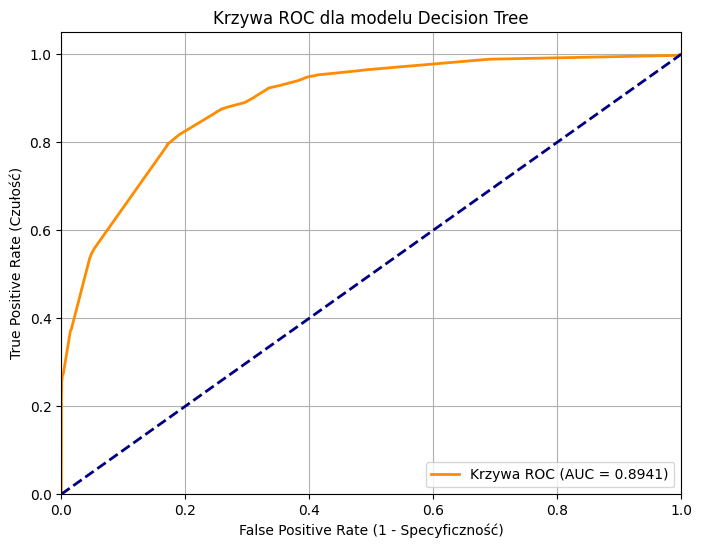

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

# =====================================================================
# 1. ŁADOWANIE I WSTĘPNE PRZYGOTOWANIE DANYCH (DATA PREPARATION)
# =====================================================================
df = pd.read_csv('adult.csv')

# Czyszczenie: zamiana znaków '?' lub ' ?' na NaN i usunięcie duplikatów/braków
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)
df = df.dropna()
df = df.drop_duplicates()

# Usunięcie kolumny 'education', ponieważ 'education_num' dubluje tę informację
if 'education' in df.columns:
    df = df.drop(columns=['education'])

# Zmienna docelowa (Target) - mapowanie na wartości 0 i 1
target_column = 'income'
df[target_column] = df[target_column].str.strip()
df[target_column] = df[target_column].map({'<=50K': 0, '>50K': 1})

# Zamiana pozostałych zmiennych kategorycznych (tekstowych) na postać numeryczną (One-Hot Encoding)
X = df.drop(columns=[target_column])
y = df[target_column]
X = pd.get_dummies(X, drop_first=True)

# =====================================================================
# 2. PODZIAŁ NA ZBIÓR UCZĄCY I TESTOWY (TRAIN/TEST SPLIT)
# =====================================================================
# Podział 70% treningowy, 30% testowy.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# =====================================================================
# 3. BUDOWA I TRENOWANIE MODELU (MODEL BUILDING)
# =====================================================================
# Wybieramy Drzewo Decyzyjne. Parametry zbliżone do modelu w Oracle SQL Developer (warianta bazowy).
model = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=20, random_state=42)
model.fit(X_train, y_train)

# Predykcja klas oraz prawdopodobieństw (potrzebnych do wykresu ROC)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# =====================================================================
# 4. OCENA JAKOŚCI MODELU (EVALUATION METRICS)
# =====================================================================
print("--- METRYKI KLASYFIKACJI ---")
print(f"Accuracy (Ogólna dokładność): {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Precyzja):         {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Czułość):             {recall_score(y_test, y_pred):.4f}")

# Generowanie i wyświetlenie Macierzy Pomyłek
cm = confusion_matrix(y_test, y_pred)
print("\n--- MACIERZ POMYŁEK (CONFUSION MATRIX) ---")
print(f"True Negative (Rzeczywiste <=50K, Przewidziane <=50K): {cm[0,0]}")
print(f"False Positive (Rzeczywiste <=50K, Przewidziane >50K):  {cm[0,1]}")
print(f"False Negative (Rzeczywiste >50K, Przewidziane <=50K): {cm[1,0]}")
print(f"True Positive (Rzeczywiste >50K, Przewidziane >50K):  {cm[1,1]}")

# =====================================================================
# 5. GENEROWANIE WYKRESU ROC / AUC
# =====================================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Krzywa ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specyficzność)')
plt.ylabel('True Positive Rate (Czułość)')
plt.title('Krzywa ROC dla modelu Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()